<a href="https://colab.research.google.com/github/sfaizenn/AnalisisNumerik/blob/main/25083010009_Sandi%20Fadia%20Aizena_Analisis%20Numerik%20Kapal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama: Sandi Fadia Aizena**

**NPM: 25083010009**

**Mata Kuliah: Analisis Numerik (A)**

**Link Github:** https://github.com/sfaizenn/AnalisisNumerik


Pada tugas ini dilakukan perhitungan volume kedua lambung kapal berdasarkan gambar dan data yang diberikan. **Ketentuan yang digunakan dalam perhitungan:**
1. Skala Horizontal: Satu dash-kosong $= 5 + 5\text{ cm} = 10\text{ cm}$ (jarak antar titik/stasiun $L = 10\text{ cm}$).   
2. Skala Vertikal: Skala kotak garis ke atas (tinggi lambung $h$) $= 45\text{ cm}$.   
3. Lantai kapal dianggap datar dan tidak memiliki keel (tinggi $h = 45\text{ cm}$ konstan).   
4. Tampak depan kapal dianggap berbentuk persegi panjang.   
5. Volume reserve buoyancy tidak dihitung.

**1. Import Library dan Pemuatan Gambar Desain**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 40.0 MB/s eta 0:00:00


Saving perahu.pdf to perahu.pdf


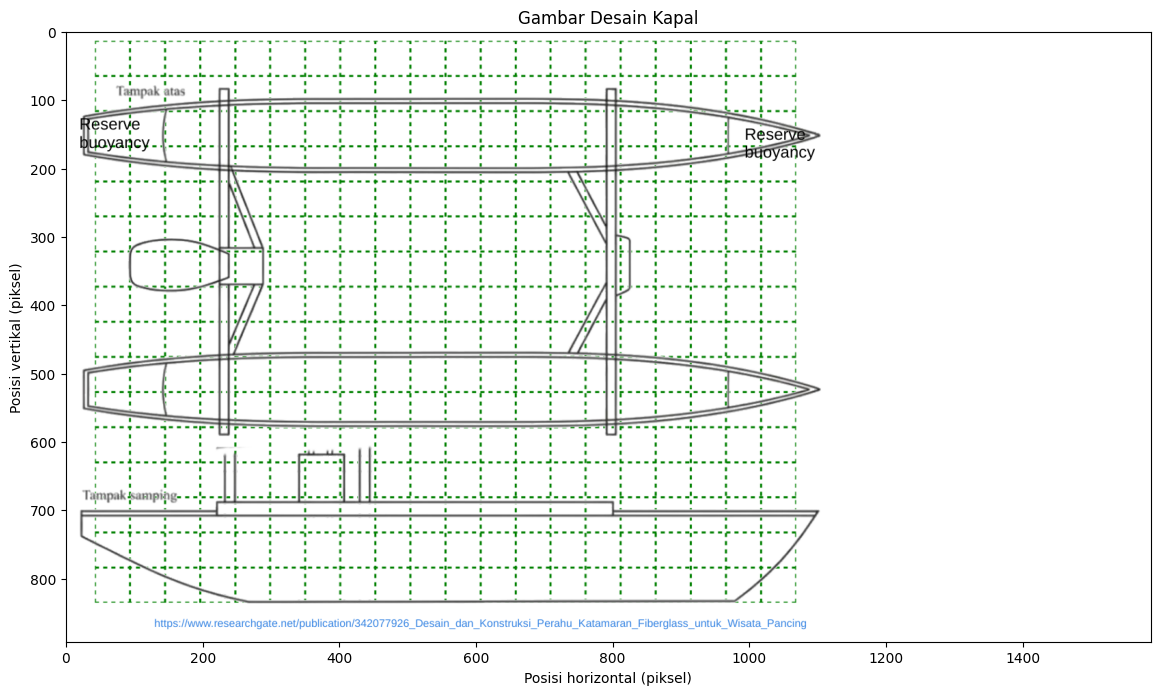

Ukuran gambar: 1588 x 893


In [ ]:
!pip install -q pymupdf
import fitz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from google.colab import files

uploaded = files.upload()
nama_file = next(iter(uploaded))

pdf = fitz.open(nama_file)
halaman = pdf[0]

gambar = halaman.get_pixmap(matrix=fitz.Matrix(2, 2), alpha=False)
gambar_array = np.frombuffer(
    gambar.samples, dtype=np.uint8
).reshape(gambar.height, gambar.width, 3)

plt.figure(figsize=(14, 8))
plt.imshow(gambar_array)
plt.title("Gambar Desain Kapal")
plt.xlabel("Posisi horizontal (piksel)")
plt.ylabel("Posisi vertikal (piksel)")
plt.show()

print("Ukuran gambar:", gambar.width, "x", gambar.height)

**2. Deteksi Grid dan Kalibrasi Skala**


In [ ]:
# Deteksi garis grid hijau
R, G, B = gambar_array[:, :, 0], gambar_array[:, :, 1], gambar_array[:, :, 2]
hijau = (G > 100) & (R < 90) & (B < 90)

def cari_garis(proyeksi, rasio=0.25):
    idx = np.where(proyeksi > rasio * proyeksi.max())[0]
    kelompok = np.split(idx, np.where(np.diff(idx) > 3)[0] + 1)
    return np.array([k.mean() for k in kelompok if len(k) > 0])

x_garis = cari_garis(hijau.sum(axis=0))
y_garis = cari_garis(hijau.sum(axis=1))

PX_PER_KOTAK = float(np.median(np.diff(x_garis)))
X0 = float(x_garis[0])   # piksel x dari garis grid paling kiri
Y0 = float(y_garis[0])   # piksel y dari garis grid paling atas

# Kalau hasil deteksi aneh, isi manual di sini, contoh:
# PX_PER_KOTAK, X0, Y0 = 94.2, 76, 26

KOTAK_CM = 45   # 1 kotak = 45 cm (skala revisi)

print(f"Jumlah garis vertikal  : {len(x_garis)}")
print(f"Jumlah garis horizontal: {len(y_garis)}")
print(f"Piksel per kotak       : {PX_PER_KOTAK:.2f}")
print(f"Origin grid (X0, Y0)   : ({X0:.1f}, {Y0:.1f}) piksel")
print(f"1 piksel = {KOTAK_CM / PX_PER_KOTAK:.4f} cm")

Jumlah garis vertikal  : 21
Jumlah garis horizontal: 17
Piksel per kotak       : 51.50
Origin grid (X0, Y0)   : (43.0, 15.0) piksel
1 piksel = 0.8738 cm


**3. Pembacaan Dimensi Lambung dan Verifikasi dengan Overlay**

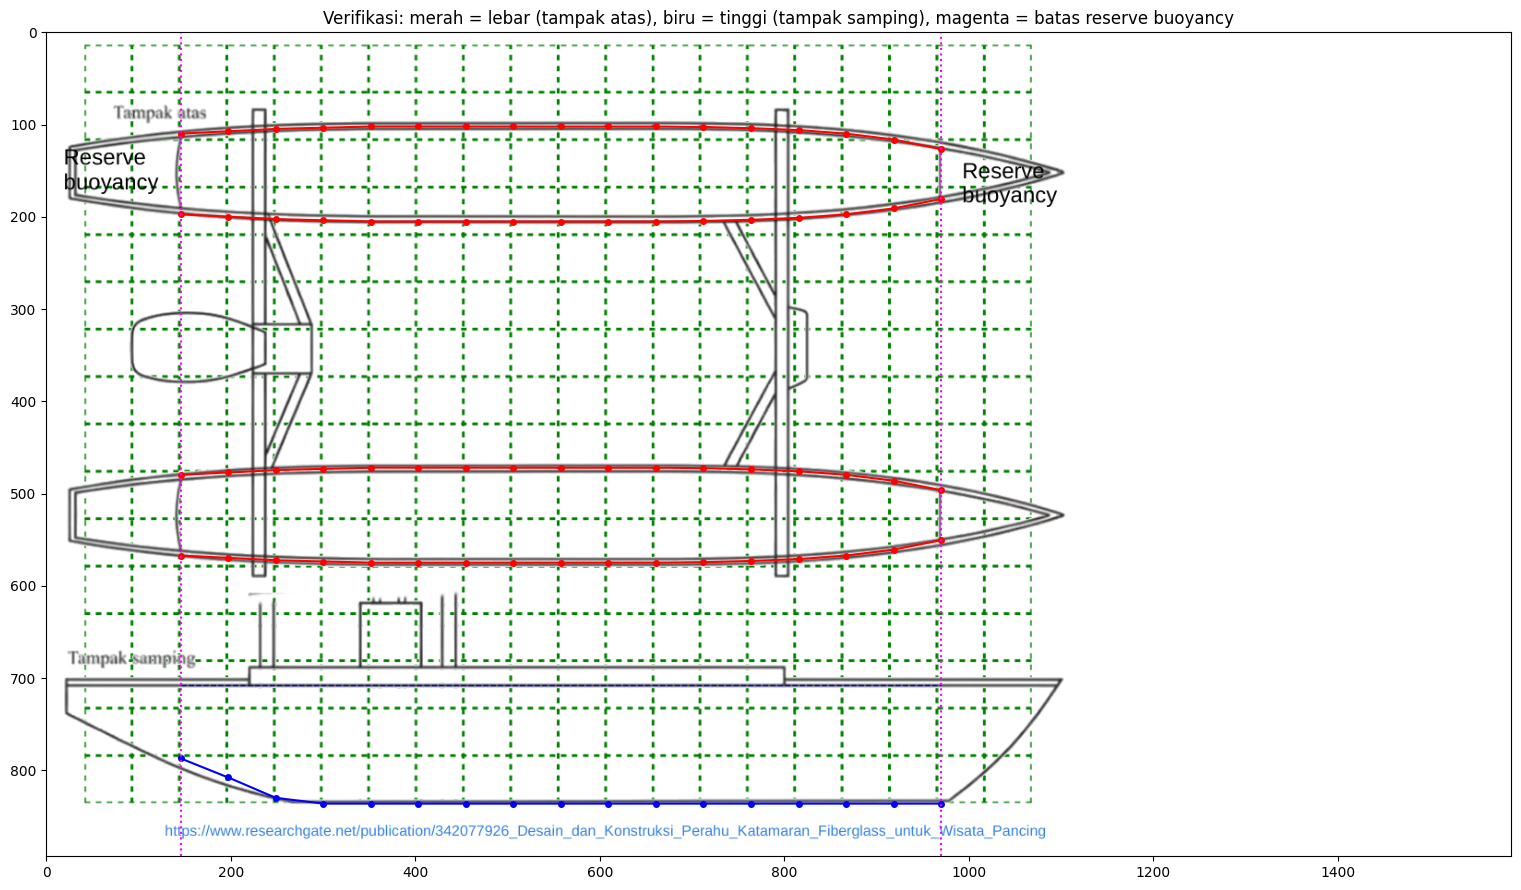

In [ ]:
# Posisi x (kotak): dari batas reserve buoyancy kiri (2) ke kanan (18)
x = np.arange(2, 19)          # 2,3,...,18  (17 titik, 16 interval)

# Lebar lambung dari TAMPAK ATAS (kotak)
w = np.array([1.70, 1.80, 1.90, 1.95, 2.00, 2.00, 2.00, 2.00, 2.00,
              2.00, 2.00, 1.98, 1.93, 1.85, 1.70, 1.45, 1.05])

# Tinggi/sarat lambung dari TAMPAK SAMPING (kotak), dari garis deck ke dasar datar
d = np.array([1.55, 1.95, 2.38] + [2.50] * 14)

# Posisi referensi (kotak)
YC_ATAS  = 2.69    # garis tengah lambung atas (tampak atas)
YC_BAWAH = 9.87    # garis tengah lambung bawah (tampak atas)
Y_DECK   = 13.44   # garis deck pada tampak samping

assert len(x) == len(w) == len(d)

# Overlay untuk verifikasi
def px(X): return X0 + X * PX_PER_KOTAK
def py(Y): return Y0 + Y * PX_PER_KOTAK

fx = np.linspace(x[0], x[-1], 300)
wi = np.interp(fx, x, w)
di = np.interp(fx, x, d)

fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(gambar_array)

for yc in (YC_ATAS, YC_BAWAH):
    ax.plot(px(fx), py(yc - wi / 2), "r-", lw=1.5)
    ax.plot(px(fx), py(yc + wi / 2), "r-", lw=1.5)
    ax.plot(px(x), py(yc - w / 2), "ro", ms=4)
    ax.plot(px(x), py(yc + w / 2), "ro", ms=4)

ax.plot(px(fx), py(Y_DECK + di), "b-", lw=1.5)
ax.plot(px(x), py(Y_DECK + d), "bo", ms=4)
ax.plot(px(fx), py(Y_DECK + 0 * fx), "b--", lw=1)

for xb in (x[0], x[-1]):
    ax.axvline(px(xb), color="magenta", ls=":", lw=1.5)

ax.set_title("Verifikasi: merah = lebar (tampak atas), biru = tinggi (tampak samping), "
             "magenta = batas reserve buoyancy")
ax.set_xlim(0, gambar.width); ax.set_ylim(gambar.height, 0)
plt.tight_layout()
plt.show()

**4. Perhitungan Volume, Tabel Hasil, dan Grafik**

Karena tampak depan lambung berbentuk persegi panjang, luas penampang pada posisi $x$ dihitung dengan:

$$A(x) = w(x) \cdot d(x)$$

Volume satu lambung diperoleh dengan mengintegrasikan luas penampang sepanjang lambung:

$$V = \int_{x_0}^{x_n} A(x)\,dx$$

Integrasi dilakukan secara numerik menggunakan dua metode, yaitu **aturan trapesium** dan **aturan Simpson 1/3**. Volume kedua lambung diperoleh dengan mengalikan volume satu lambung dengan 2, karena kedua lambung memiliki bentuk yang identik.

Hasil perhitungan disajikan dalam dua tabel, yaitu Tabel 1 (tabel penampang) dan Tabel 2 (hasil volume), serta grafik lebar lambung dan luas penampang.

TABEL 1. Tabel Penampang Lambung


No,x (kotak),x (cm),Lebar w (kotak),Lebar w (cm),Tinggi d (kotak),Tinggi d (cm),Luas A = w·d (cm²),Luas A (m²)
1,2,90.0,1.70,76.5,1.55,69.8,"5,335.9",0.5336
2,3,135.0,1.80,81.0,1.95,87.8,"7,107.8",0.7108
3,4,180.0,1.90,85.5,2.38,107.1,"9,157.0",0.9157
4,5,225.0,1.95,87.8,2.50,112.5,"9,871.9",0.9872
5,6,270.0,2.00,90.0,2.50,112.5,"10,125.0",1.0125
6,7,315.0,2.00,90.0,2.50,112.5,"10,125.0",1.0125
7,8,360.0,2.00,90.0,2.50,112.5,"10,125.0",1.0125
8,9,405.0,2.00,90.0,2.50,112.5,"10,125.0",1.0125
9,10,450.0,2.00,90.0,2.50,112.5,"10,125.0",1.0125
10,11,495.0,2.00,90.0,2.50,112.5,"10,125.0",1.0125



TABEL 2. Hasil Perhitungan Volume Kedua Lambung


Metode,1 lambung (cm³),1 lambung (m³),2 lambung (cm³),2 lambung (m³),2 lambung (liter)
Trapesium,"6,634,994",6.6350,"13,269,987",13.2700,"13,270.0"
Simpson 1/3,"6,645,868",6.6459,"13,291,736",13.2917,"13,291.7"



Selisih Trapesium vs Simpson: 0.1639 %


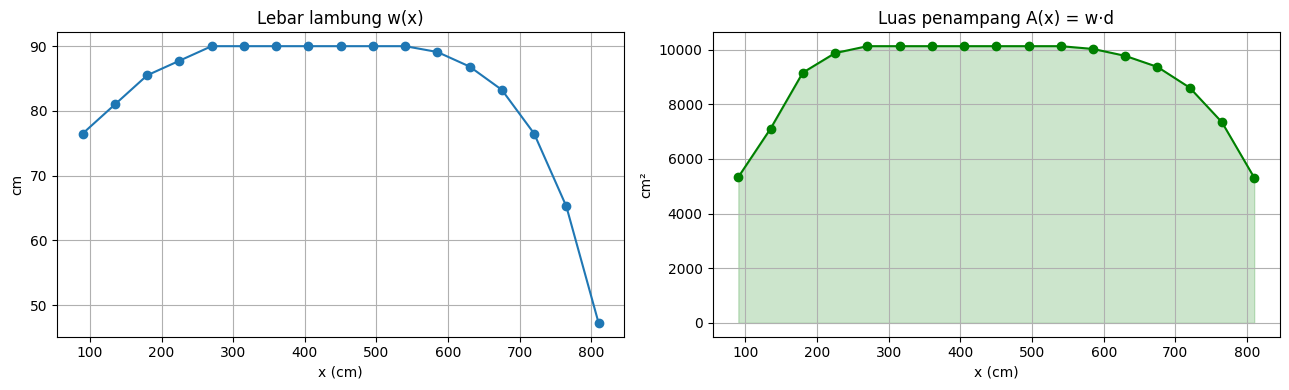

In [ ]:
# Konversi ke cm
x_cm = x * KOTAK_CM
w_cm = w * KOTAK_CM
d_cm = d * KOTAK_CM

# Luas penampang (tampak depan = persegi panjang)
A_cm2 = w_cm * d_cm

# Integrasi numerik (1 lambung)
V_trap = np.sum((A_cm2[1:] + A_cm2[:-1]) / 2 * np.diff(x_cm))   # trapesium
V_simp = simpson(A_cm2, x=x_cm)                                  # Simpson 1/3

# TABEL 1: Tabel penampang
tabel_penampang = pd.DataFrame({
    "No": np.arange(1, len(x) + 1),
    "x (kotak)": x,
    "x (cm)": x_cm,
    "Lebar w (kotak)": w,
    "Lebar w (cm)": w_cm,
    "Tinggi d (kotak)": d,
    "Tinggi d (cm)": d_cm,
    "Luas A = w·d (cm²)": A_cm2,
    "Luas A (m²)": A_cm2 / 1e4,
})

# TABEL 2: Hasil volume
tabel_volume = pd.DataFrame({
    "Metode": ["Trapesium", "Simpson 1/3"],
    "1 lambung (cm³)": [V_trap, V_simp],
    "1 lambung (m³)": [V_trap / 1e6, V_simp / 1e6],
    "2 lambung (cm³)": [2 * V_trap, 2 * V_simp],
    "2 lambung (m³)": [2 * V_trap / 1e6, 2 * V_simp / 1e6],
    "2 lambung (liter)": [2 * V_trap / 1e3, 2 * V_simp / 1e3],
})

# Selisih antar metode
selisih = abs(V_trap - V_simp) / V_trap * 100

print("TABEL 1. Tabel Penampang Lambung")
display(
    tabel_penampang.style
    .format({
        "x (kotak)": "{:.0f}", "x (cm)": "{:,.1f}",
        "Lebar w (kotak)": "{:.2f}", "Lebar w (cm)": "{:,.1f}",
        "Tinggi d (kotak)": "{:.2f}", "Tinggi d (cm)": "{:,.1f}",
        "Luas A = w·d (cm²)": "{:,.1f}", "Luas A (m²)": "{:.4f}",
    })
    .hide(axis="index")
    .set_table_styles([{"selector": "th", "props": [("background-color", "#1f4e79"),
                                                    ("color", "white"),
                                                    ("text-align", "center")]}])
)

print("\nTABEL 2. Hasil Perhitungan Volume Kedua Lambung")
display(
    tabel_volume.style
    .format({
        "1 lambung (cm³)": "{:,.0f}", "1 lambung (m³)": "{:.4f}",
        "2 lambung (cm³)": "{:,.0f}", "2 lambung (m³)": "{:.4f}",
        "2 lambung (liter)": "{:,.1f}",
    })
    .hide(axis="index")
    .set_table_styles([{"selector": "th", "props": [("background-color", "#1f4e79"),
                                                    ("color", "white"),
                                                    ("text-align", "center")]}])
)

print(f"\nSelisih Trapesium vs Simpson: {selisih:.4f} %")

# Grafik
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].plot(x_cm, w_cm, "o-")
axs[0].set_title("Lebar lambung w(x)")
axs[0].set_xlabel("x (cm)"); axs[0].set_ylabel("cm"); axs[0].grid(True)

axs[1].plot(x_cm, A_cm2, "o-", color="green")
axs[1].fill_between(x_cm, A_cm2, alpha=0.2, color="green")
axs[1].set_title("Luas penampang A(x) = w·d")
axs[1].set_xlabel("x (cm)"); axs[1].set_ylabel("cm²"); axs[1].grid(True)
plt.tight_layout(); plt.show()

### **Kesimpulan**

Berdasarkan perhitungan dengan skala 1 kotak = 45 cm, diperoleh hasil sebagai berikut:

| Metode | Volume 1 lambung | Volume 2 lambung |
|---|---|---|
| Aturan trapesium | 6,635 m³ | 13,270 m³ |
| Aturan Simpson 1/3 | 6,646 m³ | 13,292 m³ |

Volume satu lambung perahu katamaran ini sekitar **6,64 m³**. Karena kedua lambung bentuknya identik, volume totalnya sekitar **13,27 m³** (trapesium) sampai **13,29 m³** (Simpson 1/3), atau setara dengan kurang lebih 13.270 sampai 13.292 liter. Kedua metode memberikan hasil yang hampir sama, dengan selisih hanya sekitar **0,16%**. Artinya, hasil perhitungan ini cukup konsisten dan interval 1 kotak yang dipakai sudah memadai untuk bentuk lambung pada gambar. Dari grafik terlihat bahwa lebar lambung bertambah dari ujung kiri, mencapai nilai maksimum sekitar 90 cm di bagian tengah (x ≈ 270 sampai 540 cm), lalu mengecil ke arah ujung kanan yang meruncing. Tinggi lambung dianggap konstan sebesar 112,5 cm setelah bagian awal, sehingga luas penampang maksimumnya sekitar 10.125 cm² dan bentuk grafiknya mengikuti pola lebar lambung. Perlu diingat bahwa hasil ini bergantung pada pembacaan lebar dan tinggi lambung secara visual dari gambar, jadi masih ada kemungkinan selisih kecil dari nilai sebenarnya. Perhitungan ini juga mengasumsikan lantai kapal datar (tanpa keel) dan tidak memasukkan volume *reserve buoyancy*, sesuai ketentuan pada soal.